In [1]:
!pip install nltk
!pip install Sastrawi #library bahasa indonesia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 2.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd

import re

In [4]:
#ambil file csv yang sudah di generet di twiter
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/datafix.csv", encoding='latin-1')
data.head(10)

,text,label
0,"Hai, ini merupakan sebuah komentar.\nUntuk mu...",Non-Spam
1,Saya mau download formulir n persyaratan biki...,Non-Spam
2,"<a HREF=""alert(&#039;OpenVAS-XSS-Test&#039;)""...",Spam
3,2Ls9XR9VWMCWCbOPXgQkHhW563V,Spam
4,Saya juga sangat mengapresiasi gaya penul...,Non-Spam
5,Aku pun benar-benar menghargai gaya bahas...,Non-Spam
6,"Halo, baru saja mengetahui blog Anda melalui G...",Spam
7,Cody Rotschild Menikmati Kehidupan Kampus di M...,Spam
8,Apakah Anda keberatan jika saya mengutip beber...,Spam
9,"Apa yang Terjadi Saya baru dalam hal ini, saya...",Spam


In [5]:
# Jumlah total data
total_data = len(data)
print("Total data:", total_data)

# Jumlah data berdasarkan label
label_counts = data['label'].value_counts()
print("\nJumlah data berdasarkan label:")
print(label_counts)

Total data: 1446

Jumlah data berdasarkan label:
label
Spam        1002
Non-Spam     444
Name: count, dtype: int64


In [6]:
import pandas as pd
import re
import string

# Fungsi untuk membersihkan teks dan case folding
def cleaning(kalimat):
    if not kalimat or kalimat.strip() == "":
        return None

    # Ganti semua jenis URL dan HTML link jadi 'link'
    kalimat = re.sub(r'https?://\S+|www\.\S+|\S+\.(com|org|net)\S*', 'link', kalimat, flags=re.IGNORECASE)
    kalimat = re.sub(r'\[url=.*?\].*?\[/url\]', 'link', kalimat, flags=re.IGNORECASE)
    kalimat = re.sub(r'<a\s+(?:[^>]*?\s+)?href="[^"]*".*?</a>', 'link', kalimat, flags=re.IGNORECASE | re.DOTALL)
    kalimat = re.sub(r'<.*?>', '', kalimat)

    # Hapus kata-kata acak panjang di dalam kalimat
    kalimat = re.sub(r'\b[a-zA-Z0-9]{12,}\b', '', kalimat)

    # Jika seluruh kalimat hanya string acak panjang
    if re.fullmatch(r'[A-Za-z0-9]{12,}', kalimat.strip()):
        return None

    # Lanjutkan dengan normalisasi
    kalimat = re.sub(r'\t|\n|\r', ' ', kalimat)
    kalimat = kalimat.encode('ascii', 'ignore').decode('ascii')
    kalimat = re.sub(r'\d+', '', kalimat)
    kalimat = kalimat.translate(str.maketrans("", "", string.punctuation))
    kalimat = re.sub(r'&\w+;', '', kalimat)
    kalimat = kalimat.lower()
    kalimat = ' '.join([word for word in kalimat.split() if len(word) > 1])
    kalimat = re.sub(r'\s+', ' ', kalimat).strip()

    return kalimat if kalimat else None




# Buat DataFrame
df = pd.DataFrame(data)

# Terapkan fungsi cleaning ke kolom 'text'
df['text_clean'] = df['text'].apply(cleaning)

# Hapus duplikat dan NaN
df_cleaned = df.drop_duplicates(subset=['text_clean']).dropna(subset=['text_clean'])



print("\nContoh hasil cleaning:\n", df_cleaned[['text', 'text_clean']].head())



Contoh hasil cleaning:
                                                 text  \
0   Hai, ini merupakan sebuah komentar.\nUntuk mu...   
1   Saya mau download formulir n persyaratan biki...   
2   <a HREF="alert(&#039;OpenVAS-XSS-Test&#039;)"...   
4   Saya  juga  sangat   mengapresiasi gaya penul...   
5   Aku  pun  benar-benar menghargai   gaya bahas...   

                                          text_clean  
0  hai ini merupakan sebuah komentar untuk mulai ...  
1  saya mau download formulir persyaratan bikin s...  
2                                               link  
4  saya juga sangat gaya penulisan yang jelas dan...  
5  aku pun benarbenar menghargai gaya bahasa yang...  


In [7]:
#tokenisasi
import nltk
nltk.download('all')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

In [8]:
def token(kalimat):
  tokens = nltk.tokenize.word_tokenize(kalimat)

  return tokens

In [9]:
# Fungsi token sederhana
def token(kalimat):
    if isinstance(kalimat, str):
        return kalimat.split()
    return []

# Pastikan tidak ada NaN
df = df.dropna(subset=['text_clean'])

# Tokenisasi
df['token'] = df['text_clean'].apply(token)
df.head(20)

<ipython-input-9-2c5ddb6e2a9d>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['token'] = df['text_clean'].apply(token)


,text,label,text_clean,token
0,"Hai, ini merupakan sebuah komentar.\nUntuk mu...",Non-Spam,hai ini merupakan sebuah komentar untuk mulai ...,"[hai, ini, merupakan, sebuah, komentar, untuk,..."
1,Saya mau download formulir n persyaratan biki...,Non-Spam,saya mau download formulir persyaratan bikin s...,"[saya, mau, download, formulir, persyaratan, b..."
2,"<a HREF=""alert(&#039;OpenVAS-XSS-Test&#039;)""...",Spam,link,[link]
4,Saya juga sangat mengapresiasi gaya penul...,Non-Spam,saya juga sangat gaya penulisan yang jelas dan...,"[saya, juga, sangat, gaya, penulisan, yang, je..."
5,Aku pun benar-benar menghargai gaya bahas...,Non-Spam,aku pun benarbenar menghargai gaya bahasa yang...,"[aku, pun, benarbenar, menghargai, gaya, bahas..."
6,"Halo, baru saja mengetahui blog Anda melalui G...",Spam,halo baru saja mengetahui blog anda melalui go...,"[halo, baru, saja, mengetahui, blog, anda, mel..."
7,Cody Rotschild Menikmati Kehidupan Kampus di M...,Spam,cody rotschild menikmati kehidupan kampus di m...,"[cody, rotschild, menikmati, kehidupan, kampus..."
8,Apakah Anda keberatan jika saya mengutip beber...,Spam,apakah anda keberatan jika saya mengutip beber...,"[apakah, anda, keberatan, jika, saya, mengutip..."
9,"Apa yang Terjadi Saya baru dalam hal ini, saya...",Spam,apa yang terjadi saya baru dalam hal ini saya ...,"[apa, yang, terjadi, saya, baru, dalam, hal, i..."
10,"Halo semua, sebenarnya menyenangkan bagi saya ...",Spam,halo semua sebenarnya bagi saya untuk mengunju...,"[halo, semua, sebenarnya, bagi, saya, untuk, m..."


In [10]:
#library bahasa indonesia
#stopword
from Sastrawi.StopWordRemover.StopWordRemoverFactory import  StopWordRemoverFactory
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()
print(stopwords)

['yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'menurut', 'antara', 'dia', 'dua', 'ia', 'seperti', 'jika', 'jika', 'sehingga', 'kembali', 'dan', 'tidak', 'ini', 'karena', 'kepada', 'oleh', 'saat', 'harus', 'sementara', 'setelah', 'belum', 'kami', 'sekitar', 'bagi', 'serta', 'di', 'dari', 'telah', 'sebagai', 'masih', 'hal', 'ketika', 'adalah', 'itu', 'dalam', 'bisa', 'bahwa', 'atau', 'hanya', 'kita', 'dengan', 'akan', 'juga', 'ada', 'mereka', 'sudah', 'saya', 'terhadap', 'secara', 'agar', 'lain', 'anda', 'begitu', 'mengapa', 'kenapa', 'yaitu', 'yakni', 'daripada', 'itulah', 'lagi', 'maka', 'tentang', 'demi', 'dimana', 'kemana', 'pula', 'sambil', 'sebelum', 'sesudah', 'supaya', 'guna', 'kah', 'pun', 'sampai', 'sedangkan', 'selagi', 'sementara', 'tetapi', 'apakah', 'kecuali', 'sebab', 'selain', 'seolah', 'seraya', 'seterusnya', 'tanpa', 'agak', 'boleh', 'dapat', 'dsb', 'dst', 'dll', 'dahulu', 'dulunya', 'anu', 'demikian', 'tapi', 'ingin', 'juga', 'nggak', 'mari', 'nanti', 'melainkan', '

In [11]:
def stopwords_text(tokens):
    cleaned_tokens = []
    for token in tokens:
        if token not in stopwords:
            cleaned_tokens.append(token)

    return cleaned_tokens

In [12]:
df['stop'] = df['token'].apply(stopwords_text)
df.head()

,text,label,text_clean,token,stop
0,"Hai, ini merupakan sebuah komentar.\nUntuk mu...",Non-Spam,hai ini merupakan sebuah komentar untuk mulai ...,"[hai, ini, merupakan, sebuah, komentar, untuk,...","[hai, merupakan, sebuah, komentar, mulai, memo..."
1,Saya mau download formulir n persyaratan biki...,Non-Spam,saya mau download formulir persyaratan bikin s...,"[saya, mau, download, formulir, persyaratan, b...","[mau, download, formulir, persyaratan, bikin, ..."
2,"<a HREF=""alert(&#039;OpenVAS-XSS-Test&#039;)""...",Spam,link,[link],[link]
4,Saya juga sangat mengapresiasi gaya penul...,Non-Spam,saya juga sangat gaya penulisan yang jelas dan...,"[saya, juga, sangat, gaya, penulisan, yang, je...","[sangat, gaya, penulisan, jelas, mudah, dipaha..."
5,Aku pun benar-benar menghargai gaya bahas...,Non-Spam,aku pun benarbenar menghargai gaya bahasa yang...,"[aku, pun, benarbenar, menghargai, gaya, bahas...","[aku, benarbenar, menghargai, gaya, bahasa, je..."


In [13]:
#stemming
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

In [14]:
def stem_text(tokens):
  hasil = [stemmer.stem(token) for token in tokens]
  return hasil

In [15]:
df['stemmed'] = df['stop'].apply(stem_text)
df.head(20)

,text,label,text_clean,token,stop,stemmed
0,"Hai, ini merupakan sebuah komentar.\nUntuk mu...",Non-Spam,hai ini merupakan sebuah komentar untuk mulai ...,"[hai, ini, merupakan, sebuah, komentar, untuk,...","[hai, merupakan, sebuah, komentar, mulai, memo...","[hai, rupa, buah, komentar, mulai, memoderasi,..."
1,Saya mau download formulir n persyaratan biki...,Non-Spam,saya mau download formulir persyaratan bikin s...,"[saya, mau, download, formulir, persyaratan, b...","[mau, download, formulir, persyaratan, bikin, ...","[mau, download, formulir, syarat, bikin, siup,..."
2,"<a HREF=""alert(&#039;OpenVAS-XSS-Test&#039;)""...",Spam,link,[link],[link],[link]
4,Saya juga sangat mengapresiasi gaya penul...,Non-Spam,saya juga sangat gaya penulisan yang jelas dan...,"[saya, juga, sangat, gaya, penulisan, yang, je...","[sangat, gaya, penulisan, jelas, mudah, dipaha...","[sangat, gaya, tulis, jelas, mudah, paham, fra..."
5,Aku pun benar-benar menghargai gaya bahas...,Non-Spam,aku pun benarbenar menghargai gaya bahasa yang...,"[aku, pun, benarbenar, menghargai, gaya, bahas...","[aku, benarbenar, menghargai, gaya, bahasa, je...","[aku, benarbenar, harga, gaya, bahasa, jelas, ..."
6,"Halo, baru saja mengetahui blog Anda melalui G...",Spam,halo baru saja mengetahui blog anda melalui go...,"[halo, baru, saja, mengetahui, blog, anda, mel...","[halo, baru, mengetahui, blog, melalui, google...","[halo, baru, tahu, blog, lalu, google, temu, b..."
7,Cody Rotschild Menikmati Kehidupan Kampus di M...,Spam,cody rotschild menikmati kehidupan kampus di m...,"[cody, rotschild, menikmati, kehidupan, kampus...","[cody, rotschild, menikmati, kehidupan, kampus...","[cody, rotschild, nikmat, hidup, kampus, montr..."
8,Apakah Anda keberatan jika saya mengutip beber...,Spam,apakah anda keberatan jika saya mengutip beber...,"[apakah, anda, keberatan, jika, saya, mengutip...","[keberatan, mengutip, beberapa, posting, selam...","[berat, kutip, beberapa, posting, lama, beri, ..."
9,"Apa yang Terjadi Saya baru dalam hal ini, saya...",Spam,apa yang terjadi saya baru dalam hal ini saya ...,"[apa, yang, terjadi, saya, baru, dalam, hal, i...","[apa, terjadi, baru, menemukan, merasa, sangat...","[apa, jadi, baru, temu, rasa, sangat, bantu, b..."
10,"Halo semua, sebenarnya menyenangkan bagi saya ...",Spam,halo semua sebenarnya bagi saya untuk mengunju...,"[halo, semua, sebenarnya, bagi, saya, untuk, m...","[halo, semua, sebenarnya, mengunjungi, halaman...","[halo, semua, benar, unjung, halaman, web, isi..."


In [16]:
# Ubah hasil stemming (list kata) jadi string
df['stemmed_str'] = df['stemmed'].apply(lambda x: ' '.join(x))

# Siapkan fitur dan label
X = df['stemmed_str']   # hasil akhir dari semua preprocessing
y = df['label']         # target label

# Simpan ke CSV dengan kolom stemmed_str
df.to_csv('hasil_stemmed.csv', columns=['text', 'text_clean', 'stemmed_str', 'label'], index=False)


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Ubah label ke numerik
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])  # spam = 1, non-spam = 0

# Tampilkan jumlah label sebelum split
print("Jumlah label sebelum split:")
print(df['label'].value_counts())
print("\nJumlah label numerik:")
print(df['label_encoded'].value_counts())

# Split data
train_size = 0.8
X_train, X_test, y_train, y_test = train_test_split(
    df['stemmed_str'],
    df['label_encoded'],
    train_size=train_size,
    random_state=42,
    stratify=df['label_encoded']
)

# Tampilkan jumlah label setelah split
print("\nJumlah label di data train:")
print(y_train.value_counts())

print("\nJumlah label di data test:")
print(y_test.value_counts())

print(f"\nJumlah data train: {len(X_train)}")
print(f"Jumlah data test: {len(X_test)}")


Jumlah label sebelum split:
label
Spam        1001
Non-Spam     443
Name: count, dtype: int64

Jumlah label numerik:
label_encoded
1    1001
0     443
Name: count, dtype: int64

Jumlah label di data train:
label_encoded
1    801
0    354
Name: count, dtype: int64

Jumlah label di data test:
label_encoded
1    200
0     89
Name: count, dtype: int64

Jumlah data train: 1155
Jumlah data test: 289


TF-IDF DataFrame (Top 5 Rows):
   aads  aam  aan  aart  abadi  abahya  abai  abcpchsgcl  abet  about  ...  \
0   0.0  0.0  0.0   0.0    0.0     0.0   0.0         0.0   0.0    0.0  ...   
1   0.0  0.0  0.0   0.0    0.0     0.0   0.0         0.0   0.0    0.0  ...   
2   0.0  0.0  0.0   0.0    0.0     0.0   0.0         0.0   0.0    0.0  ...   
3   0.0  0.0  0.0   0.0    0.0     0.0   0.0         0.0   0.0    0.0  ...   
4   0.0  0.0  0.0   0.0    0.0     0.0   0.0         0.0   0.0    0.0  ...   

   zavoranudbz  zejswifjwn  zetten  zitten  ziyaret  \
0          0.0         0.0     0.0     0.0  0.00000   
1          0.0         0.0     0.0     0.0  0.00000   
2          0.0         0.0     0.0     0.0  0.32348   
3          0.0         0.0     0.0     0.0  0.00000   
4          0.0         0.0     0.0     0.0  0.00000   

   zjiazoodpmptspsidoarjokabgoidvmytd  zona  zoster  \
0                                 0.0   0.0     0.0   
1                                 0.0   0.0     0.0   
2   

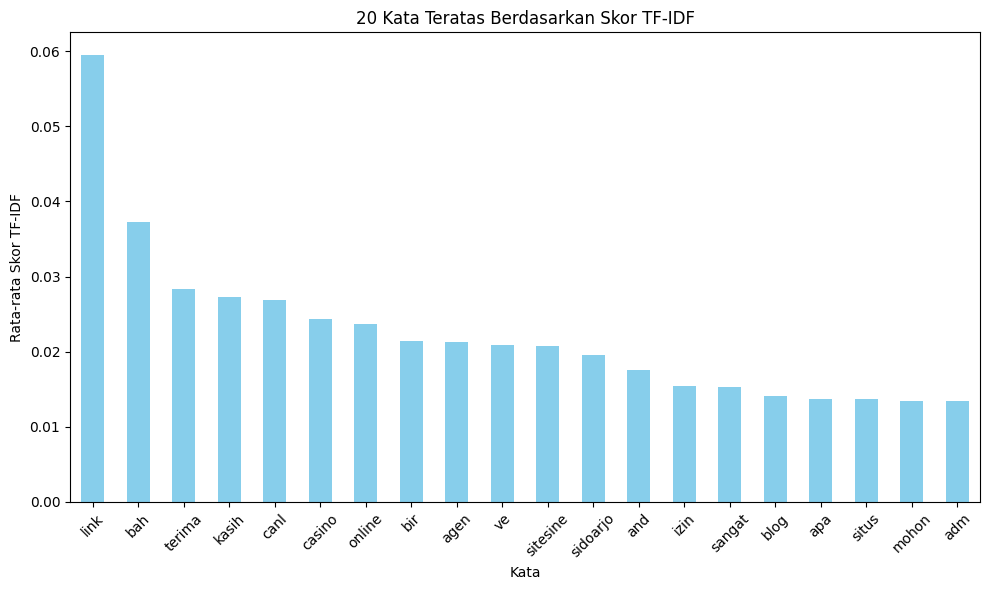

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE
import numpy as np

# Langkah 1: Melatih TfidfVectorizer dengan data pelatihan
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)  # fit_transform pada data pelatihan
X_test_tfidf = tfidf.transform(X_test)  # transform hanya untuk data uji

# Ubah ke dense array
X_train_tfidf_array = X_train_tfidf.toarray()
X_test_tfidf_array = X_test_tfidf.toarray()

# Ubah ke DataFrame untuk melihat top kata
tfidf_df = pd.DataFrame(X_train_tfidf_array, columns=tfidf.get_feature_names_out())  # Gunakan array yang dense untuk DataFrame
print("TF-IDF DataFrame (Top 5 Rows):")
print(tfidf_df.head())

# Rata-rata skor tiap kata
mean_tfidf = tfidf_df.mean().sort_values(ascending=False)

# Tampilkan 20 kata paling tinggi
top_20_words = mean_tfidf.head(20)
print("\nTop 20 kata berdasarkan skor TF-IDF:")
print(top_20_words)

# Plot
plt.figure(figsize=(10, 6))
top_20_words.plot(kind='bar', color='skyblue')
plt.title('20 Kata Teratas Berdasarkan Skor TF-IDF')
plt.ylabel('Rata-rata Skor TF-IDF')
plt.xlabel('Kata')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [19]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

def calculate_N_percent(y_train, minority_class=0):
    count = Counter(y_train)
    T = count[minority_class]
    M = max([v for k, v in count.items() if k != minority_class])
    N_percent = ((M - T) / T) * 100
    return int(N_percent)

def apply_smote_custom(X, y, N_percent=32, k_neighbors=5, minority_class=0):
    y = np.array(y)
    T = np.sum(y == minority_class)
    majority_count = np.sum(y != minority_class)

    if T <= k_neighbors:
        raise ValueError(f"Jumlah data minoritas ({T}) kurang dari atau sama dengan k_neighbors ({k_neighbors}). SMOTE akan error.")

    synthetic_count = int((N_percent / 100) * T)
    target_total = T + synthetic_count
    sampling_ratio = target_total / majority_count

    smote = SMOTE(sampling_strategy=sampling_ratio, k_neighbors=k_neighbors, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)

    return X_resampled, y_resampled, Counter(y), Counter(y_resampled)

# Terapkan SMOTE
N = calculate_N_percent(y_train, minority_class=0)
X_train_smote, y_train_smote, before, after = apply_smote_custom(
    X_train_tfidf_array, y_train, N_percent=N, k_neighbors=5, minority_class=0
)

print("Sebelum SMOTE:", before)
print("Setelah SMOTE:", after)


Sebelum SMOTE: Counter({np.int64(1): 801, np.int64(0): 354})
Setelah SMOTE: Counter({np.int64(1): 801, np.int64(0): 800})


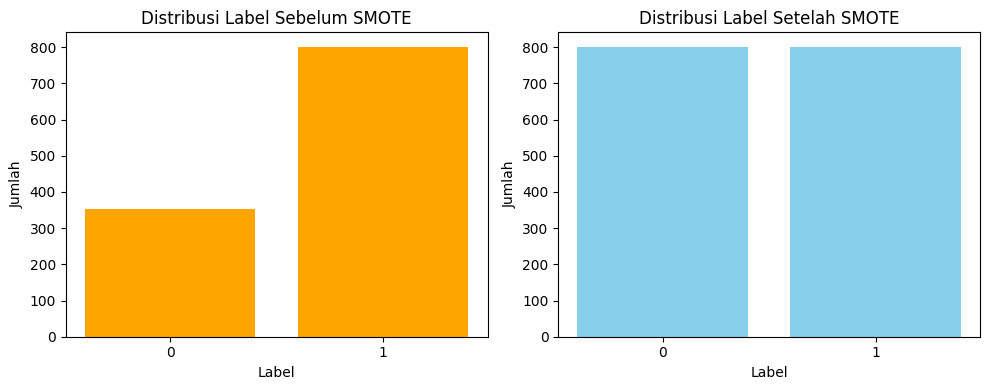

In [20]:
import matplotlib.pyplot as plt

# Buat dua bar chart: sebelum dan sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sebelum SMOTE
axes[0].bar(before.keys(), before.values(), color='orange')
axes[0].set_title("Distribusi Label Sebelum SMOTE")
axes[0].set_xticks(list(before.keys()))
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Jumlah")

# Setelah SMOTE
axes[1].bar(after.keys(), after.values(), color='skyblue')
axes[1].set_title("Distribusi Label Setelah SMOTE")
axes[1].set_xticks(list(after.keys()))
axes[1].set_xlabel("Label")
axes[1].set_ylabel("Jumlah")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


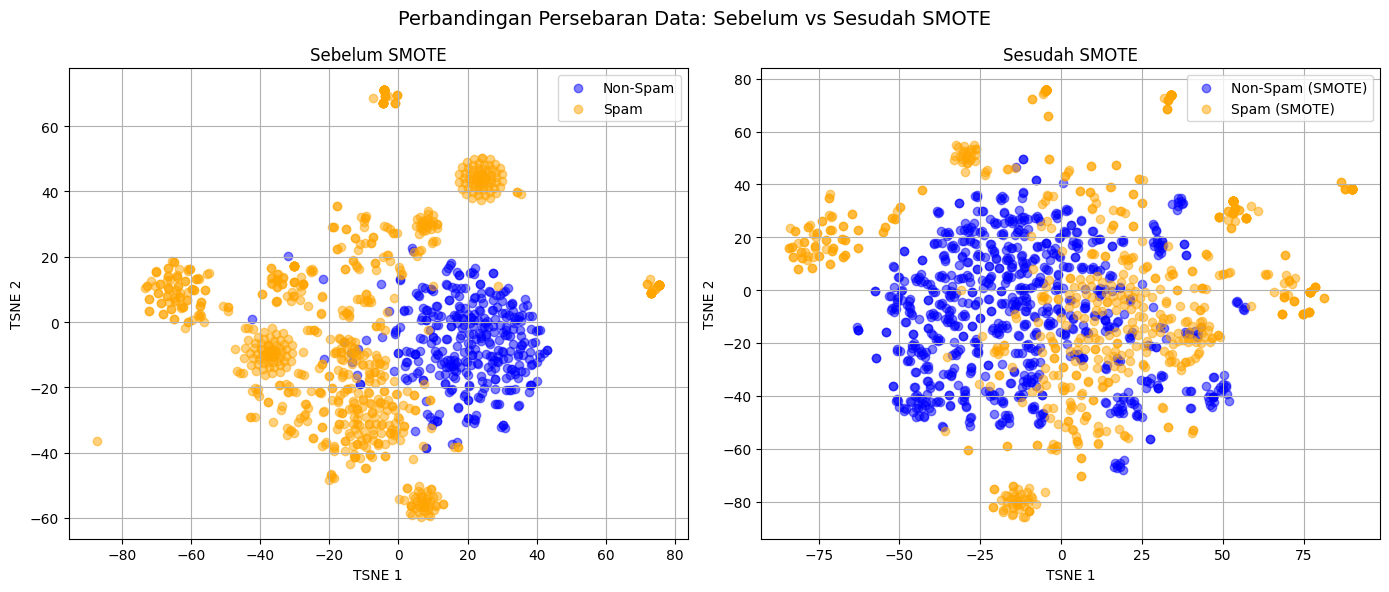

In [21]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# TSNE sebelum SMOTE
tsne_before = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_before_tsne = tsne_before.fit_transform(X_train_tfidf_array)

# TSNE sesudah SMOTE
tsne_after = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_after_tsne = tsne_after.fit_transform(X_train_smote)

# Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot sebelum SMOTE
axes[0].scatter(X_before_tsne[np.array(y_train) == 0, 0], X_before_tsne[np.array(y_train) == 0, 1],
                alpha=0.5, label='Non-Spam', c='blue')
axes[0].scatter(X_before_tsne[np.array(y_train) == 1, 0], X_before_tsne[np.array(y_train) == 1, 1],
                alpha=0.5, label='Spam', c='orange')
axes[0].set_title("Sebelum SMOTE")
axes[0].set_xlabel("TSNE 1")
axes[0].set_ylabel("TSNE 2")
axes[0].legend()
axes[0].grid(True)

# Plot sesudah SMOTE
axes[1].scatter(X_after_tsne[np.array(y_train_smote) == 0, 0], X_after_tsne[np.array(y_train_smote) == 0, 1],
                alpha=0.5, label='Non-Spam (SMOTE)', c='blue')
axes[1].scatter(X_after_tsne[np.array(y_train_smote) == 1, 0], X_after_tsne[np.array(y_train_smote) == 1, 1],
                alpha=0.5, label='Spam (SMOTE)', c='orange')
axes[1].set_title("Sesudah SMOTE")
axes[1].set_xlabel("TSNE 1")
axes[1].set_ylabel("TSNE 2")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Perbandingan Persebaran Data: Sebelum vs Sesudah SMOTE", fontsize=14)
plt.tight_layout()
plt.show()



🎯 Akurasi Model: 0.9827

📊 Classification Report:
              precision    recall  f1-score   support

    Non-Spam       1.00      0.94      0.97        89
        Spam       0.98      1.00      0.99       200

    accuracy                           0.98       289
   macro avg       0.99      0.97      0.98       289
weighted avg       0.98      0.98      0.98       289



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


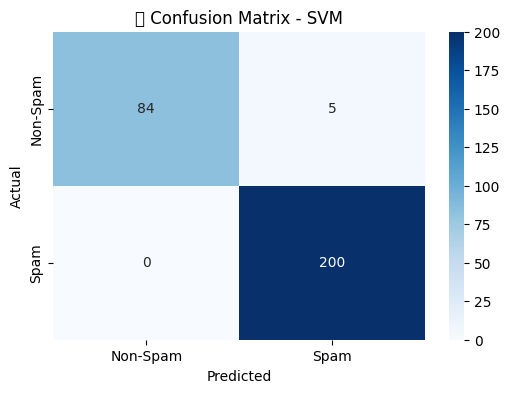

In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Inisialisasi dan latih model
model = SVC(kernel='linear', C=1)
model.fit(X_train_smote, y_train_smote)

# Prediksi test
y_pred = model.predict(X_test_tfidf_array)

# Evaluasi
acc = accuracy_score(y_test, y_pred)
print(f"\n🎯 Akurasi Model: {acc:.4f}\n")

print("📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-Spam", "Spam"]))

conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non-Spam", "Spam"], yticklabels=["Non-Spam", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("📌 Confusion Matrix - SVM")
plt.show()


📚 Akurasi Training: 0.9931


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


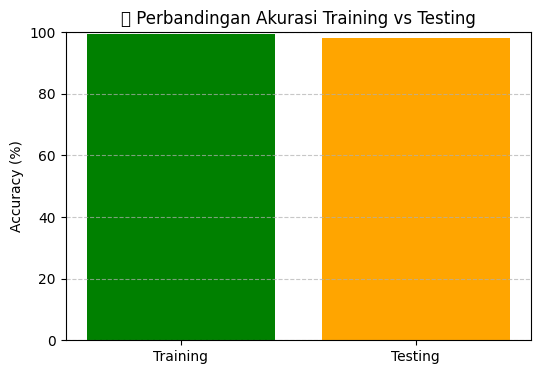

In [23]:
# =====================
# Akurasi di data training
# =====================
y_train_pred = model.predict(X_train_smote)
train_acc = accuracy_score(y_train_smote, y_train_pred)
print(f"📚 Akurasi Training: {train_acc:.4f}")

# =====================
# Plot Perbandingan Akurasi Training vs Testing
# =====================
plt.figure(figsize=(6,4))
plt.bar(["Training", "Testing"], [train_acc * 100, acc * 100], color=["green", "orange"])
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.title("🎯 Perbandingan Akurasi Training vs Testing")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [24]:
import pickle

# Simpan model SVM yang sudah dilatih
with open('svm_modelasli.pkl', 'wb') as file:
    pickle.dump(model, file)

# Simpan juga vectorizer TF-IDF karena nanti diperlukan di aplikasi Flask
with open('tfidf_vectorizerasli.pkl', 'wb') as file:
    pickle.dump(tfidf, file)

print("✅ Model dan TF-IDF vectorizer berhasil disimpan!")


✅ Model dan TF-IDF vectorizer berhasil disimpan!
